<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/DSTNM_300426_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Differential Binary Noise Modulation

# v1:  
1) Alterando a matri referencia X0 para [1 -1 ; 1 1] e nao a identidade
2) Conferir se essa matriz apesar de alterara constelação resultante, mantem a estrutura de DISTANCIA DO CODIGO. Por que D é a escolha?
3) Abaixo tem dois grafico, mas eles sao os mesmos para DSTM, rodar com 1M e ve se vao fazer diferença e deletar um deles.




Para o futuro:
1) Usando eq 22 a distancia do codigo é distancia do produto e se mantem com 4 para DSTM?
2) A eq 22 escolhe D deve ser normalizado (Pot=1) ou deve ser unitaria? Por que?
Resposta: Estou usando a pot=1, por isso raiz(4). A matriz fica uma quase unitaria (escalar da I e não a propria I ).

3) Como det(G) e a distanccia produto (G) se comportam antes e depois de D?
4) Posso começar com um ruido pequeno em D e ir aumentando e tornando distancia cada vez menor.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc

In [2]:
# A segundo ideia agora é retirar o alfabeto e deixar ruido
#  alphabet -> noise_alphabet
# 1) A mudança da ancora (matriz identidade)
# 2) Alfabeto deve ser estatistico (não deve pertencer a um alfabeto fixo).


# Vamos gerar ao novo :    Quaternion Rotated Noise Codebook    C={Gi​Z}i=18​
# ==========================
# MATRIZES GERADORAS  = origem dos quaternios - ficará algo ponto de partida e talvez haja comparação
# ==========================
I = np.eye(2, dtype=complex)

g1 = np.array([[1j, 0],
               [0, -1j]], dtype=complex)

g2 = np.array([[0, -1],
               [1,  0]], dtype=complex)

g1g2 = g1 @ g2

# Alfabeto quaternionico
alphabet = [
    I, -I,
    g1, -g1,
    g2, -g2,
    g1g2, -g1g2
]

# ==========================
# FUNÇÃO DE NORMALIZAÇÃO
# ==========================
def normalize_fro(M):                                # só normaliza energia, não torna unitário.
    return M / np.linalg.norm(M, 'fro')

# ==========================
# GERAR BASE NOISE MATRIX
# ==========================

def generate_base_noise():
    A = np.random.randn(2,2) + 1j*np.random.randn(2,2) # gera novo ruido "BASE" = NORMAL (0,1)
    Q, R = np.linalg.qr(A)                             # com : Q^HQ=I  então Z^HZ= (1/2)​I    ok
    return (1/np.sqrt(2))*Q                            # normaliza = potencia = 1. Q tem potencia igual n (caso=2). Mas ao multiplicar passar a ter potencia = 1 similar a X_prev = alfa*I
    # Como $Q$ é uma matriz unitária (derivada da decomposição QR), o seu determinante é sempre um número complexo com módulo igual a 1.
    # $$|\det(Q)| = 1$$
    # multiplicamos a matriz por um escalar $c$, o determinante é multiplicado por $c^n$  Logo fica: \det(Z) = \frac{1}{2} \det(Q)  = METADE DE Q

# ==========================
# GERAR NOISE CODEBOOK                                  # gerar o ALFABETO = CODEBOOK
# ==========================                            # usa a BASE para cada codigo
def generate_noise_codebook():
    Z = generate_base_noise()   # base e normalizada

    codebook = []

    for G in alphabet:          # para cada item do alfabeto cria un Nk
        Nk = G @ Z              # Nk = G @ Z
        Nk = normalize_fro(Nk)  # nao é mais necessario pois agora usa função com Q,R
        codebook.append(Nk)

    return codebook

In [3]:
# TEste pode deletar
from numpy.linalg import matrix_power
A = np.random.randn(2,2) + 1j*np.random.randn(2,2) # gera novo ruido "BASE" = NORMAL (0,1)
Q, R = np.linalg.qr(A)                           #  com : Q^HQ=I  necessario para
Z = (1/np.sqrt(2))*Q                             # então Z^HZ= (1/2)​I    ok
print(Z)
############
X_prev =  (1/np.sqrt(4)) *np.array([[1,-1],[1,1]]) # Eq 22  (Pot=1 com raiz(4), apos essa normalização fica 0,5I )
Z = X_prev
#  outro caso
# rng = np.random.default_rng()
# H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  ## pot = 2 para ser potencia = 1 usar 2 e nao raiz(2)
# Z = H
############
# Qual a potencia?   É unitaria?
energia = np.linalg.norm(Z, 'fro')**2
print("")
print("A energia de Z = ",energia)
print("")
print("Verificando se Z^H*Z = I: ")
unitaria = Z.conj().T @ Z     # hermitiana  ou np.dot(Z.conj().T, Z)
print(np.around(unitaria,2))  #

[[-0.03296076+0.08469322j -0.53061653+0.45846128j]
 [ 0.70109611+0.01431414j -0.07942688-0.04416701j]]

A energia de Z =  1.0

Verificando se Z^H*Z = I: 
[[0.5 0. ]
 [0.  0.5]]


In [4]:
def run_simulation_dstnm(snr_db_range, num_blocks):

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!)
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ). Duvida acho que o 2 aqui é para dividir por t antenas.
        ########### TESTE101 NA LINHA ABAIXO
        #sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante


        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0


        # TESTE PARA DEPURAR   = use o seed no parentese ou não
        seed = 42 # Define a semente (pode ser qualquer número inteiro ou ussar aleatorio definir isso depis)
        rng = np.random.default_rng()
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) deixa a potencia total igual a 2!!!!


        ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
        #Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
        #X_prev = (1/np.sqrt(2)) * Q
        ###########
        X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22
        #print("Valor de X_prev \n")
        #print(np.around(X_prev,2))  #


        #################### alterando de alfabeto para codebook
        #noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
        ####################
        # Primeira observação (referência)
        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        ############### TEste H=1 e N=0
        # H = np.eye(2, dtype=complex)  # sem distorcer o canal para matriz 2x2   # identidade (nao precisa normalizar aqui)
        # noise = np.zeros((1,2), dtype=complex)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN
        #print("Valor de Y_prev após canal \n")
        #print(np.around(Y_prev,2))  #

        skip_next = False  # controle do overhead extra
        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)

                # reinicializa referência

                ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
                #Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
                #X_prev = (1/np.sqrt(2)) * Q
                ###########
                X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22

                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)   # INICO de um novo FRAME
                #idx = 4 # induzir um loop para bit = "100"
                ####### Mudança de alfabeto fixo para codebook
                #noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
                #Nk_true = noise_codebook[idx]      # Nk veio de    --> Nk = G @ Z
                G_true = alphabet[idx]
                #######

                # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
                #X_curr =   X_prev @ Nk_true      # Eq 13 ok para DSTM .
                X_curr =   X_prev @ G_true        # Eq 13 ok para DSTM .


                #X_curr = X_curr / np.linalg.norm(X_curr,'fro')        # Isso pode alterar estrutura diferencial ideal.???
                #??????????????? isso de normalizar acho qque esta errado. Já é o simbolo esse X


                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #
            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            #Nk_true = noise_codebook[idx]
            G_true = alphabet[idx]

            #######

            X_curr =   X_prev @ G_true
            #X_curr = X_curr / np.linalg.norm(X_curr,'fro')     # Isso pode alterar estrutura diferencial ideal.???
            #?????????????????????????????????????????????????????????????????????????????????????????????????????

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)


            metrics_diff = []
            for G in alphabet:     # vai testar cada uma das matrizes
                val = np.real(np.trace(G @ M))
                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)

            # ==========================
            # DETECTOR COERENTE
            # ==========================
            metrics_coh = []
            for G in alphabet:
                X_test =  X_prev @ G
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1

            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...
            # ==========================
            # contagem de erros de bit
            # ==========================
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits


            X_prev = X_curr
            Y_prev = Y_curr



        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


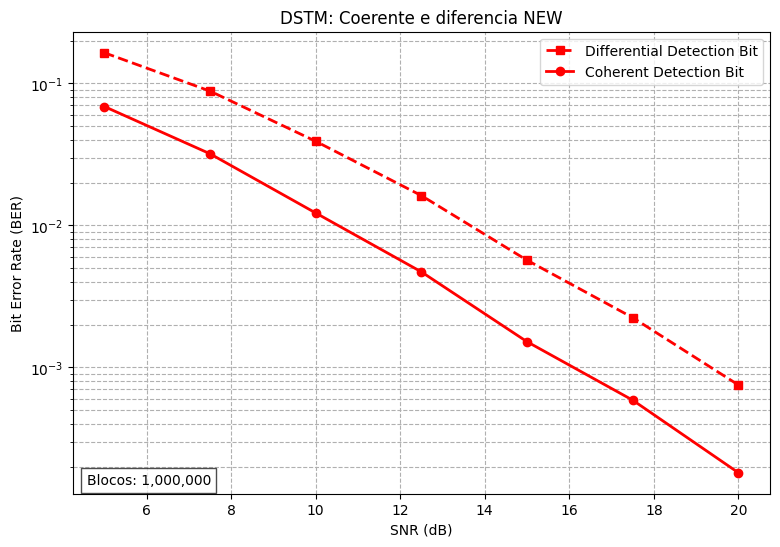

In [5]:
# --- Execução e Plotagem  DSTM  ---  Funcionando ok com Eq 22 e nao identidade.

snr_range = np.arange(5, 21, 2.5)
num_blocks=1000000

ser_diff, ser_coh, ber_diff, ber_coh = run_simulation_dstnm(snr_range, num_blocks) # 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo
                                                                                          # 16s          2mi         12min      27min

plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Bit')
plt.semilogy(snr_range, ber_coh, 'r-o', linewidth=2, markersize=6, label='Coherent Detection Bit')



# Usamos 0.02 (2%) para não colar o texto exatamente na linha do gráfico
plt.text(0.02, 0.02, f'Blocos: {num_blocks:,d}',
         transform=plt.gca().transAxes,
         fontsize=10,
         color='black',
         bbox=dict(facecolor='white', alpha=0.7))
plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('DSTM: Coerente e diferencia NEW')
plt.legend()

plt.show()


In [ ]:
print(ber_diff)
print(ber_coh)


[0.16398014010746106, 0.07512072366183772, 0.04420866489832007, 0.007209413044956811, 0.009725906277630416, 0.00047609331428960077, 0.0]
[0.07236618377201931, 0.01941780588995443, 0.015711079371556826, 0.0010882132898048017, 0.0035366931918656055, 0.0, 0.0]


# Explicação do código acima.

# V1 = com melhora!

# DSTM corrigido

1) X0 foi atualizado para Eq 22.
2) Feito teste de valores . Simulação com 300K mostra bons resultados.
3) Verificar se o CANAL RAYLEIGH deve ser normalizado por 1/sqrt(2).
4) Verificar se normalizar ou deixar a unitaria a matriz X0 (faz diferença na BER).


Passos aqui. Verificar como o determinante do alfabeto ficou? Sugestão é em vez de usar um ruido base e multiplicar pelo Quaternios. E jogar um ruido no X0 e aumentar esse ruido até ficar bem ruim.

Outro passo é mudar a matriz X0 (eq 22) por outra. OU assocciar a matriz ruido completa.



In [ ]:
def run_simulation_miso(snr_db_range, num_blocks):  # DSTM ORIGINAL E CORRIGIDO simular 500k = bom
# Alterado a matriz X_0 inicial de identidade para eq 22

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!). Duvida acho que o 2 aqui é para dividir por t antenas.
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ)
        ########### TESTE101 NA LINHA ABAIXO
        #sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante
        # matrizes de quatérnios são unitárias e o canal H é constante entre os dois blocos a metrica
        # Re Tr{GM} deve ser maxima exatamente na G enviada.
        # Resp1: O resultado que você obteve é muito revelador. O fato de o BER Coerente ser 0.0 com ruído zero prova que sua geração de canal (H), o seu alfabeto de Quatérnios (G)
        #        e a sua codificação estão funcionando perfeitamente.
        #        ou seja G e H estão respeitando os criterios de geração. O fato de BER ou SER apresentar erro (~~1/8 ) indica erro na logico do receptor diferencial apenas.
        ########### TESTE101 NA LINHA ABAIXO

        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0

        # Canal inicial (MISO 1x2)
        #H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)
        # usar esse  H abaixo para depurar (considerando o ruido zero com SNR ao infinito)
        seed = 42 # Define a semente (pode ser qualquer número inteiro)
        rng = np.random.default_rng(seed)
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) é normatizar potencia.
                                                                        # standart_normal = sigma2 = 1 ai fica H=1 + 1 = 2
                                                                        # para variancia de H=2 ser unitaria divide por raiz(2)!
        # respeita o modelo de desvanecimento Rayleigh
        # |H| = \sqrt{X^2 + Y^2} segue exatamente uma Distribuição Rayleigh apesar de X e Y forem geradas Gaussianas (0,1)
        # H é uniformemente distribuída entre 0 e
        # DSTM, trabalhamos majoritariamente com Rayleigh porque é onde a modulação diferencial brilha, lidando com a mudança constante de fase dessas componentes aleatórias.


        # X0 (Eq. 22)
        #X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)  # Essa é a X_0 / np.eye = identidade e srqt(2) é para normalizar.
        X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 e unitaria = 0,5I / SE deixar unitaria é melhor que pot = 1????
        ####################################
        #H = np.eye(2, dtype=complex)    # atualizei o canal para identidade
        #print("Simulação de matrizes")
        #print("X_prev antes do bloco k 1: ")
        ##print(np.around(X_prev, decimals=2))



        # sqrt(2) = aqui é para normalizar cada antena tem potencia = 1, logo para t=2 usa-se sqrt(2). Se fosse 3 seria sqrt(3)!!!

        # Primeira observação (referência)
        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN
        ####################################
        # print("Y_prev antes do bloco k 1: ")
        # print(np.around(Y_prev, decimals=2))
        # print("")

        skip_next = False  # controle do overhead extra


        # O canal H deve ser mantido constante por pelo menos dois blocos (o atual e o anterior)
        # Essa é uma premissa
        # cada bloco é uma simulação de Monte Carlo
        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            # Gera um novo canal, novo X_0 e novo Y_0 e tag "skip_nex" indica que
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)

                # reinicializa referência
                #X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)   nao usar mais
                X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 e unitaria = 0,5I /
                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)
                #idx = 0      # ESSA LINHA DEVE SER APAGADA APENAS UM TESTE PARA SABER SE HA ERRO EM UMA MATRIZ ESPECIFICA! JUNTO COM O TESTE101
                G_true = alphabet[idx]

                # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
                X_curr =   X_prev @ G_true      # Eq 13 ok

                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #

            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            #idx = 2     # ESSA LINHA DEVE SER APAGADA APENAS UM TESTE PARA SABER SE HA ERRO EM UMA MATRIZ ESPECIFICA! JUNTO COM O TESTE101
            G_true = alphabet[idx]
            ####################################
            # print("G do alfabeto escolhida no bloco k 1 (bits100): ")
            # print(np.around(G_true, decimals=2))
            # print("")

            # Codificação diferencial (Eq. 13)
            # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
            X_curr =   X_prev @ G_true
            ####################################
            # print("X_curr =X1 no bloco k 1 (bits100): ")
            # print(np.around(X_curr, decimals=2))
            # print("")
            # print("X_prev = ", X_prev)
            # print("")
            # print("G_true = ", G_true)
            # print("")
            # print("X_curr = ", X_curr)
            # print("")

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise
            ####################################
            # print("----CANAL H=1 e Noise = 0")
            # print("Y_curr =Y1 no bloco k 1 (bits100): ")
            # print(np.around(Y_curr, decimals=2))
            # print("")
            # print("noise =", noise)
            # print("")
            # print("H = ", H)
            # print("")
            # print("Y_curr = ", Y_curr)
            # print("")

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)  M sozinho não é potencia! É matriz de correlação cruzada (curr e prev)!    "M = Memoria Diferencial"  = quanto o sinal mudou (em fase e amplitude)
            ####################################
            # print("M  no bloco k 1 (bits100): ")
            # print(np.around(M, decimals=2))
            # print("")
            # adjunta é transposta e conjugada.!
            # print("M = ", M)
            # print("")

            # G @ M é a "assinatura" do canal que ficou guardada em $M$ e tentando desfazer a rotação usando uma matriz do seu alfabeto $G$
            # Se $G$ for a matriz correta (aquela que foi realmente enviada), o produto $G M$ resultará em uma matriz onde os elementos da diagonal principal são reforçados (somados construtivamente).
            # É como se $M$ fosse um vetor de energia vindo do canal e você estivesse testando qual $G$ consegue capturar a maior parte dessa potência para a parte real.

            # O traço é a soma dos elementos da diagonal. No contexto de detecção:
            #       O traço funciona como um filtro casado (matched filter).
            #       Ele extrai a "coerência" entre a hipótese $G$ e a observação $M$.Valor Máximo:
            #       O traço de $G M$ será máximo quando a fase e a orientação de $G$ "alinharem" perfeitamente com a defasagem contida em $M$
            # Conclusão no DSTM, o detector busca a matriz que maximiza a projeção de energia na direção correta!!!!!!!!!!!!!!!!!!!
            #print("Para cada G do alfabeto fará a metrica")

            metrics_diff = []
            for G in alphabet:     # vai testar cada uma das matrizes
                #val = np.real(np.trace(G.conj().T @ M))   # parece que .conj().T  gera erro na inversão de fase ao fazer o trace idx 2 ate 7 gera erro de 1/3 sem ruido sigma_w2 = 0
                val = np.real(np.trace(G @ M))
                ############################
                # print("###################")
                # print("X_prev = ", X_prev)
                # print("G_true = ", G_true)
                # print("X_curr = ", X_curr)
                # print("Y_curr = ", Y_curr)
                # if k == 0:

                #   print("Para G=",G)
                #   print("Para M=",M)
                #   print("Para G @ M:", G @ M)
                #   print("Traço: ",val)
                ###########################
                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)
            # print("metrics_diff = ", metrics_diff)
            # print("")

            # pega o indice que deu o maior valor sera o indice de G ESTIMADO/CHAPEU

            # ==========================
            # DETECTOR COERENTE
            # ==========================
            metrics_coh = []
            for G in alphabet:
                X_test =  X_prev @ G
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1


            # print("k= ",k,"traço= ",metrics_diff, "idx da metrics é= ", idx_hat_diff, "idx de G_true é= ",idx)     # TESTE 201 AGORA SABENDO ONDE OCORRE O ERRO APOS O TESTE101
            # print("Contagem de erro por look k = ", errors_diff)


            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...




            # ==========================
            # contagem de erros de bit
            # ==========================
            # R = 1,5 é eficiencia expectral     (R = log2(M)/n) M numero de matrizes e n comprimento do bloco (t=2 e n=2)
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            # O Operador XOR (^) : iguais = 0 e diferente =1 /  A Função bin(): passa de decimal para "string binária" / O Método .count('1'): conta /
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits

            #============================
            # atualização temporal
            X_prev = X_curr
            Y_prev = Y_curr

        # teste
        #   print(f"       SNR é {snr_db} e bloco validos total é {valid_blocks} ")
        # Dica no primeiro bloco de canal todos os são validos (k:) 0,1,2...99 = 100 blocos
        # Depois no k=100 inicia um canal novo - atualiza parametro, mas pula o resto do codigo "continue"  (atualiza H, X_0, ruido =  Y_0    )
        # Depois no k=101 atualiza o X_0/ Y_0 e etc e pula o resto do codigo "continue"                     (atualiza X_atual, ruido = Y_atual)

        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

In [ ]:
# a, b, c, d = run_simulation_miso(snr_range, num_blocks=1)

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


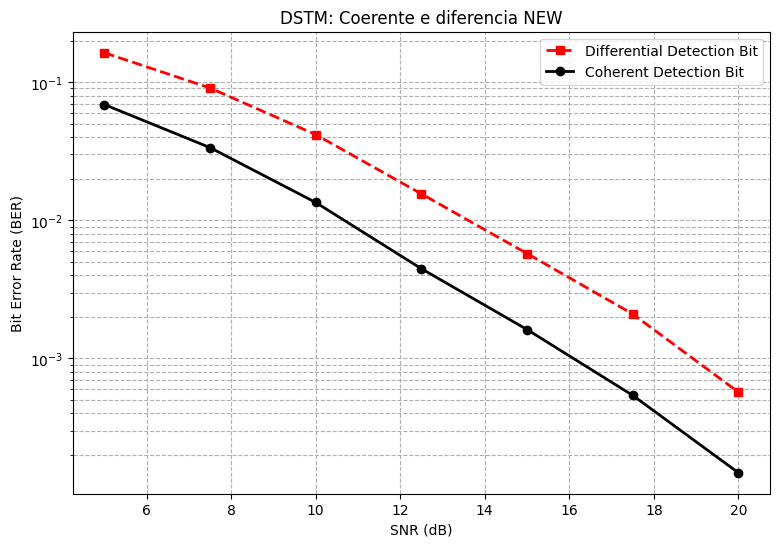

In [ ]:
# --- Execução e Plotagem  DSTNM  ---

snr_range = np.arange(5, 21, 2.5)

ser_diff, ser_coh, ber_diff, ber_coh = run_simulation_miso(snr_range, num_blocks=500000) # 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo
                                                                                          # 16s          2mi                    27min

plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Bit')
plt.semilogy(snr_range, ber_coh, 'k-o', linewidth=2, markersize=6, label='Coherent Detection Bit')

plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('DSTM: Coerente e diferencia NEW')
plt.legend()

plt.show()

In [ ]:
# Teste para saber como fica a nova constelaçao apos a entreada da matriz D  (ja normalizada pot = 1 usando determinante)
####################### APOS A MULTIPLICAÇÃO DA EQ 22
# X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 / unitaria com X_0^H @ X_0 = 0,5I  (usar multiplicaçao matricial!)
# for i in alphabet:
#   print("Para cada matriz do alfabeto i= " )
#   print(i)
#   print("")
#   print("Eq 22 (pot=1) @ o alfabeto: ")
#   print(X_prev @ i)
#   print("")
#   print("#############")
# # Conclusões: Todo o alfabeto Q8 é uma matriz unitária
######################################################
# Teste para saber como fica o determinante apos a entrada da matriz D (ja normalizada pot = 1 usando determinante)
# X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 / unitaria com X_0^H @ X_0 = 0,5I  (usar multiplicaçao matricial!)
# for i in alphabet:
#   print("Para cada matriz do alfabeto i= " )
#   print(i)
#   print("")
#   print("Determinante após (Eq 22 Eq22 @ alfabeto) (pot=1 usando determiante)" )
#   det = np.linalg.det(X_prev @ i)
#   print(f"Determinante: {det:.2f}")
#   print("")
#   print("#############")
# # Conclusões: O valor do det ficou em 0,5 para todos os alfabeto apos multiplicar pela Eq22. Antes todos era 1 do Q8. Logo a multiplicação reduziu o determinate do alfabeto.
########################################################
# #  Teste para saber o determiante de um alfabeto qq sem multiplicar pela Eq 22
# identidade = np.eye(2, dtype=complex)   # identidade ou alphabet[0]
# det = np.linalg.det(identidade) #
# print(f"Determinante: {det:.2f}")
# # Conclusão: O valor do terminante da identidade é 1. Mas da eq 22 é 0,5 acaba que a multiplicação reduziu o determinante de toda a constelação.
#########################################################
# # TESTE 7  Calculo de ZETA e LAMBDA para o alfabeto COM MULTIPLICAÇÃO EQ 22
# # Inicializa uma matriz para guardar os resultados (8x8)
# X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 / unitaria com X_0^H @ X_0 = 0,5I  (usar multiplicaçao matricial!)
# #####X_prev = 1/np.sqrt(2)*np.eye(2, dtype=complex)    # Identidade já normalizada para pot =1
# alphabetComEq22  = [matriz_do_alfabeto @ X_prev for matriz_do_alfabeto in alphabet]
# n = len(alphabetComEq22)
# dist_matrix = np.zeros((n, n))

# print("---  7- Cálculo das Distâncias de Produto com Eq 22 ---")

# for i in range(n):
#     for j in range(i + 1, n):  # Começa em i+1 para evitar a diagonal e repetições
#         diff = alphabetComEq22[i] - alphabetComEq22[j]
#         dist_prod = np.abs(np.linalg.det(diff))

#         # Como a distância é simétrica, preenchemos ambos os lados
#         dist_matrix[i, j] = dist_prod
#         dist_matrix[j, i] = dist_prod

#         # Print opcional para depuração (pode comentar se o alfabeto for grande)
#         # print(f"Distância entre G{i} e G{j}: {dist_prod:.2f}")

# # Exibindo a matriz de forma organizada
# print("\nMatriz de Distâncias de Produto (Resumo):")
# print(dist_matrix)

# # Calculando a Distância de Produto Mínima (Zeta)
# # Pegamos apenas os valores acima de zero
# dist_minima = np.min(dist_matrix[dist_matrix > 0])
# print(f"\nDistância de Produto Mínima do Alfabeto (ζ): {dist_minima}") # Lambda maiusculo é o quadrado do zeta minusculo aqui. Apenas referencia (quadratico e linear)
# print("")
# print("CONCLUSÃO: ")
# print("A multiplicação pela Eq22 reduz de 4 para 1  (Lambda = quadratica). Usando a identidade (normalizada por Frobenius com pot =1). ")
# print("Seria a mesma coisa. Logo qual a vantagem ao usar a eq22 e nao identidade. A distancia entre matrizes permanece reduzida de 4 para 1.?!")
# # Conclusão:  A multiplicação pela Eq22 reduz de 4 para 1  (lambda = quadratica). Usando a identidade (normalizada por Frobenius com pot =1). Seria a mesma coisa.
# # Logo qual a vantagem ao usar a eq22 e nao identidade. A distancia entre matrizes permanece reduzida de 4 para 1.
#############################################################
# TESTE 7  Calculo de ZETA e LAMBDA para o alfabeto sem multiplicar pela Eq22
# Inicializa uma matriz para guardar os resultados (8x8)
n = len(alphabet)
dist_matrix = np.zeros((n, n))

print("---  7- Cálculo das Distâncias de Produto Apenas alfabeto ---")

for i in range(n):
    for j in range(i + 1, n):  # Começa em i+1 para evitar a diagonal e repetições
        diff = alphabet[i] - alphabet[j]
        dist_prod = np.abs(np.linalg.det(diff))

        # Como a distância é simétrica, preenchemos ambos os lados
        dist_matrix[i, j] = dist_prod
        dist_matrix[j, i] = dist_prod

        # Print opcional para depuração (pode comentar se o alfabeto for grande)
        # print(f"Distância entre G{i} e G{j}: {dist_prod:.2f}")

# Exibindo a matriz de forma organizada
print("\nMatriz de Distâncias de Produto (Resumo):")
print(dist_matrix)

# Calculando a Distância de Produto Mínima (Zeta)
# Pegamos apenas os valores acima de zero
dist_minima = np.min(dist_matrix[dist_matrix > 0])
print(f"\nDistância de Produto Mínima do Alfabeto (ζ): {dist_minima}") # Lambda maiusculo é o quadrado do zeta minusculo aqui. Apenas referencia (quadratico e linear)


---  7- Cálculo das Distâncias de Produto ---

Matriz de Distâncias de Produto (Resumo):
[[0. 4. 2. 2. 2. 2. 2. 2.]
 [4. 0. 2. 2. 2. 2. 2. 2.]
 [2. 2. 0. 4. 2. 2. 2. 2.]
 [2. 2. 4. 0. 2. 2. 2. 2.]
 [2. 2. 2. 2. 0. 4. 2. 2.]
 [2. 2. 2. 2. 4. 0. 2. 2.]
 [2. 2. 2. 2. 2. 2. 0. 4.]
 [2. 2. 2. 2. 2. 2. 4. 0.]]

Distância de Produto Mínima do Alfabeto (ζ): 1.9999999999999996


In [ ]:
#### Teste para normalizar a energia da identidade.
# I = np.eye(2, dtype=complex)
# I = I/np.sqrt(2)
# energia = np.linalg.norm(I, 'fro')**2
# print(energia)
print("")
print(alphabet[0])


[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [ ]:
# Teste da constelação

# Como é det e produto distancia do Q8
# Como é det e produto distanccia do Q8 no primeiro bloco de bits que depende do X0
#         X1 = X0 @ G             A matriz enviada depende da matriz anterior como isso afeta o primeiro bloco?

#1 Determinante de cada elemento do alfabeto
for i in alphabet:
  print("Para i= " )
  print(i)
  print(np.linalg.det(i))
  print("#############")

Continuar aqui com v1 (alterar v2 depois de ver esses resultados de det e lambda)

Para i= 
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
(1+0j)
#############
Para i= 
[[-1.-0.j -0.-0.j]
 [-0.-0.j -1.-0.j]]
(1+0j)
#############
Para i= 
[[ 0.+1.j  0.+0.j]
 [ 0.+0.j -0.-1.j]]
(1+0j)
#############
Para i= 
[[-0.-1.j -0.-0.j]
 [-0.-0.j  0.+1.j]]
(1+0j)
#############
Para i= 
[[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]
(1+0j)
#############
Para i= 
[[-0.-0.j  1.-0.j]
 [-1.-0.j -0.-0.j]]
(1+0j)
#############
Para i= 
[[0.+0.j 0.-1.j]
 [0.-1.j 0.+0.j]]
(1+0j)
#############
Para i= 
[[-0.-0.j -0.+1.j]
 [-0.+1.j -0.-0.j]]
(1+0j)
#############


In [ ]:
usar o codigo abaixo para compor acima
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

# 111111111111111111111111111111111111111111111111111111111111111111111111111111
# Matriz UNITÁRIA  (veja que é diferente de IDENTIDADE)
############## Um alfabeto por ele mesmo (Hermetiano dá a identidade)
i = 0     # teste para todos os indice da a identidade, aqui é para o primeiro
print("1 - Matriz escolhida -indice ",i," : ")
print("")
print(alphabet[i])
print("")
teste2 = alphabet[i].conj().T@alphabet[i]      #
print("2 - Matriz unitária é diferente de IDENTIDADE")
print(teste2)
print("Tipos de dados",teste2.dtype)
print("")

#33333333333333333333333333333333333333333333333333333333333333333333333333333
# Determinante de cada alfabeto    = Sempre igual a 1
teste3 = np.linalg.det(alphabet[i])
print("3 - Determinante de cada alfabeto")
print(teste3)
print("")

# Distancia produto
print("4 - Sobre distancia dos produtos") # Usa a metrica Norma de Frobenius
# O 'r' no início é fundamental para o Python não interpretar as barras invertidas
display(Math(r'\|A\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2 }'))
print("Definição da Norma de Frobenius")   # Ela mede a Energia ou a Distância Euclidiana entre duas matrizes.
#print(np.linalg.norm(alphabet[i], ord='fro'))

# Distancia entre matrizes
print("")
print("5 - Distancia entre matrizes")
display(Math(r'\text{dist}(X, Y) = \|X - Y\|_F'))

# Calculo em python
print("")
print("     5.1 - Calculo em python:")
print("     Eq. : ", "np.linalg.norm(X - Y, 'fro')")
print("")
print("     5.2 - Exemplo:")
j = 1
teste4 = np.linalg.norm(alphabet[i] - alphabet[j], 'fro')
print("Valor em python: ", "[i,j] : ", i, j, " = ",teste4)
print("O conceito 4 e 5 não são usados no artigo e sim outro abaixo")
#???????????????????????????? NAO USAR 4 E 5 , MAS É BOM LEMBRAR DOS CONCEITOS

# 666666666666666666666666666666666666666666666666666666666666666666666
# Distancia de produto  - Determinante
print("")                   # A distância de produto entre dois símbolos $G_a$ e $G_b$ é o valor absoluto do determinante da matriz de erro:
# mede a Capacidade de Distinção das matrizes sob desvanecimento (Fading)
# É a métrica que define o Ganho de Codificação. Em canais Rayleigh, a probabilidade de erro é inversamente proporcional a essa distância de produto.
# Se o determinante da diferença for zero, seu sistema perde "diversidade total" e o desempenho despenca.
print("6 - Distancia de Produto")
display(Math(r'd_p(G_a, G_b) = |\det(G_a - G_b)|'))  # nao sei se vale para matrizes nao quadradas!!!!!
diff = alphabet[0] - alphabet[1]
dist_produto = np.abs(np.linalg.det(diff))
print(f"Distância de Produto: {dist_produto}") # Resultado: 4.0

# 7777777777777777777777777777777777777777777777777777777777777777777777
# 7  ###########################################################
# Inicializa uma matriz para guardar os resultados (8x8)
n = len(alphabet)
dist_matrix = np.zeros((n, n))

print("---  7- Cálculo das Distâncias de Produto ---")

for i in range(n):
    for j in range(i + 1, n):  # Começa em i+1 para evitar a diagonal e repetições
        diff = alphabet[i] - alphabet[j]
        dist_prod = np.abs(np.linalg.det(diff))

        # Como a distância é simétrica, preenchemos ambos os lados
        dist_matrix[i, j] = dist_prod
        dist_matrix[j, i] = dist_prod

        # Print opcional para depuração (pode comentar se o alfabeto for grande)
        # print(f"Distância entre G{i} e G{j}: {dist_prod:.2f}")

# Exibindo a matriz de forma organizada
print("\nMatriz de Distâncias de Produto (Resumo):")
print(dist_matrix)

# Calculando a Distância de Produto Mínima (Zeta)
# Pegamos apenas os valores acima de zero
dist_minima = np.min(dist_matrix[dist_matrix > 0])
print(f"\nDistância de Produto Mínima do Alfabeto (ζ): {dist_minima}")

# 8   Notações diferentes
print("")
print("8 - Notações diferentes")
display(Math(r'\Lambda_p vs. \zeta'))  #
# Muitos artigos utilizam $\Lambda_p$ para representar a distância de produto ao quadrado ou escalonada.
display(Math(r'\Lambda_p = \min_{a \neq b} |\det(G_a - G_b)|^2'))  #



# Conclusões do testes
# 2 Lembre-se que matriz unitaria é uma coisa e não quer dizer identidade
# 3 Nos quaternios Q8 cada elemento do alfabeto tem determinante = 1.
# 4 E 5 Distancia usando Norma de Frobenius que esta errada para sistema MIMO . Ex matriz diferença [ 2 0 ; 0 0]. Pela norma da uma distancia 2, mas MIMO é zero (veja abaixo)
# 6 e 7 Distancia produto pelo DETERMINANTE o calculo correto, contudo aqui é de uma forma LINEAR letra zeta minuscula (difernte da tabela I quaternios Q8 para R = 1,5 QPSK)
# 8 Apenas um esclarecimento entre Lambda maiusculo (metrica quadratica) e zeta minusculo como a matrica linear
#            Distância de Produto Mínima do Alfabeto (ζ)   = linear
#            Distância de Produto Mínima do Alfabeto (Λ_p) = quadratica


1 - Matriz escolhida -indice  0  : 

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

2 - Matriz unitária é diferente de IDENTIDADE
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Tipos de dados complex128

3 - Determinante de cada alfabeto
(1+0j)

4 - Sobre distancia dos produtos


<IPython.core.display.Math object>

Definição da Norma de Frobenius

5 - Distancia entre matrizes


<IPython.core.display.Math object>


     5.1 - Calculo em python:
     Eq. :  np.linalg.norm(X - Y, 'fro')

     5.2 - Exemplo:
Valor em python:  [i,j] :  0 1  =  2.8284271247461903
O conceito 4 e 5 não são usados no artigo e sim outro abaixo

6 - Distancia de Produto


<IPython.core.display.Math object>

Distância de Produto: 4.0
---  7- Cálculo das Distâncias de Produto ---

Matriz de Distâncias de Produto (Resumo):
[[0. 4. 2. 2. 2. 2. 2. 2.]
 [4. 0. 2. 2. 2. 2. 2. 2.]
 [2. 2. 0. 4. 2. 2. 2. 2.]
 [2. 2. 4. 0. 2. 2. 2. 2.]
 [2. 2. 2. 2. 0. 4. 2. 2.]
 [2. 2. 2. 2. 4. 0. 2. 2.]
 [2. 2. 2. 2. 2. 2. 0. 4.]
 [2. 2. 2. 2. 2. 2. 4. 0.]]

Distância de Produto Mínima do Alfabeto (ζ): 1.9999999999999996

8 - Notações diferentes


<IPython.core.display.Math object>

<IPython.core.display.Math object>